In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
# load root name
root = input("Enter root name for the run of interest: ").strip()

Surrogate Model Validation: Drawdown in 160 Perimeter Cells for 10 Stress Periods...


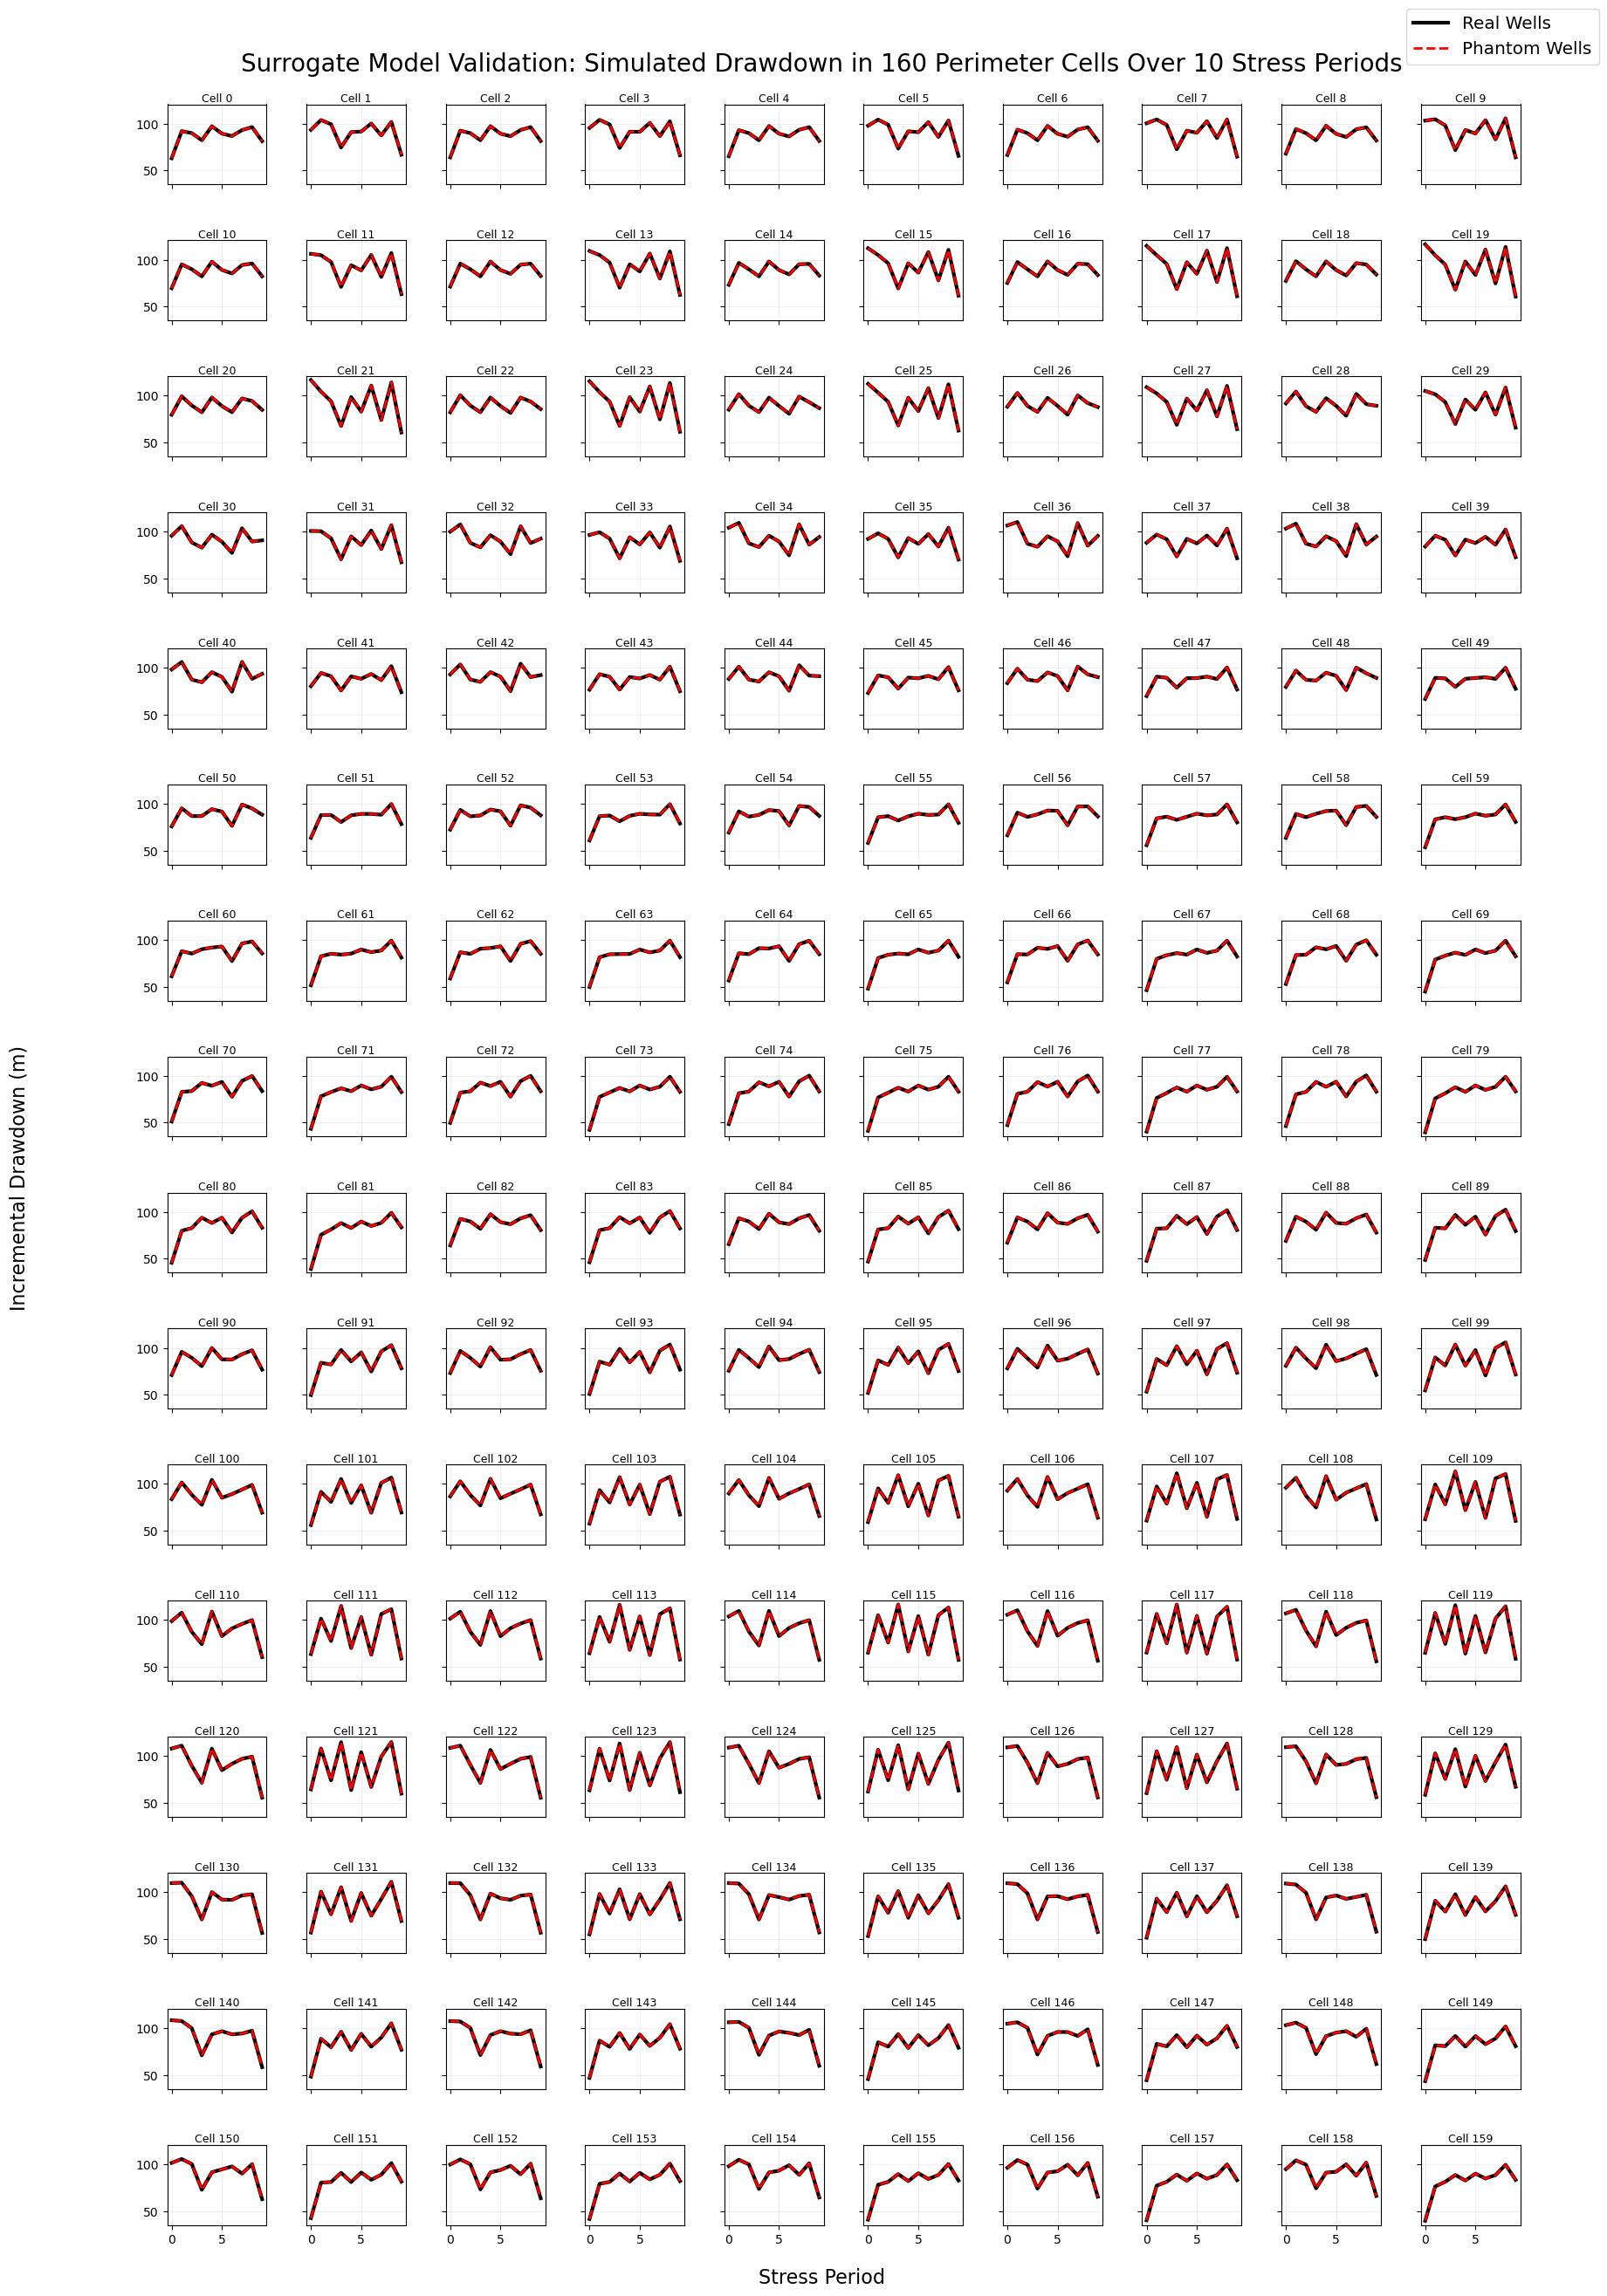

In [6]:
# load cumulative drawdown data
results_path = Path.cwd().parent / "results"
target_cum = pd.read_csv(results_path / f"{root}_target_drawdown.csv", index_col=0)
match_cum = pd.read_csv(results_path / f"{root}_surrogate_match.csv", index_col=0)

# calculate incremental drawdown by differencing the cumulative data
# fill_na(target_cum) ensures the first period remains as the initial drawdown
target_inc = target_cum.diff().fillna(target_cum.iloc[0])
match_inc = match_cum.diff().fillna(match_cum.iloc[0])

n_periods, n_cells = target_cum.shape

# set up the figure with a grid of subplots
rows, cols = 16, 10
fig, axes = plt.subplots(rows, cols, figsize=(20, 30), sharex=True, sharey=True)
axes_flat = axes.flatten()

print(f"Surrogate Model Validation: Drawdown in {n_cells} Perimeter Cells for {n_periods} Stress Periods...")

for i in range(len(axes_flat)):
    ax = axes_flat[i]
    
    if i < n_cells:
        # plot the incremental drawdown for the target and surrogate model
        ax.plot(target_inc.index, target_inc.iloc[:, i], 'black', lw=3, label='Real Wells' if i==0 else "")
        ax.plot(match_inc.index, match_inc.iloc[:, i], 'r--', lw=2, label='Phantom Wells' if i==0 else "")
        
        ax.set_title(f"Cell {i}", fontsize=9, pad=2)
        ax.grid(True, alpha=0.2)
    else:
        ax.axis('off')

# global title and legend
fig.suptitle(f"Surrogate Model Validation: Simulated Drawdown in {n_cells} Perimeter Cells Over {n_periods} Stress Periods", fontsize=20, y=0.93)
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize='x-large')

# common x and y labels
fig.text(0.5, 0.08, 'Stress Period', ha='center', va='center', fontsize=16)
fig.text(0.04, 0.5, 'Incremental Drawdown (m)', ha='center', va='center', rotation='vertical', fontsize=16)

plt.subplots_adjust(hspace=0.7, wspace=0.4, bottom=0.1, top=0.91)
plt.show()

Plotting optimized pumping rates for all 160 phantom wells...


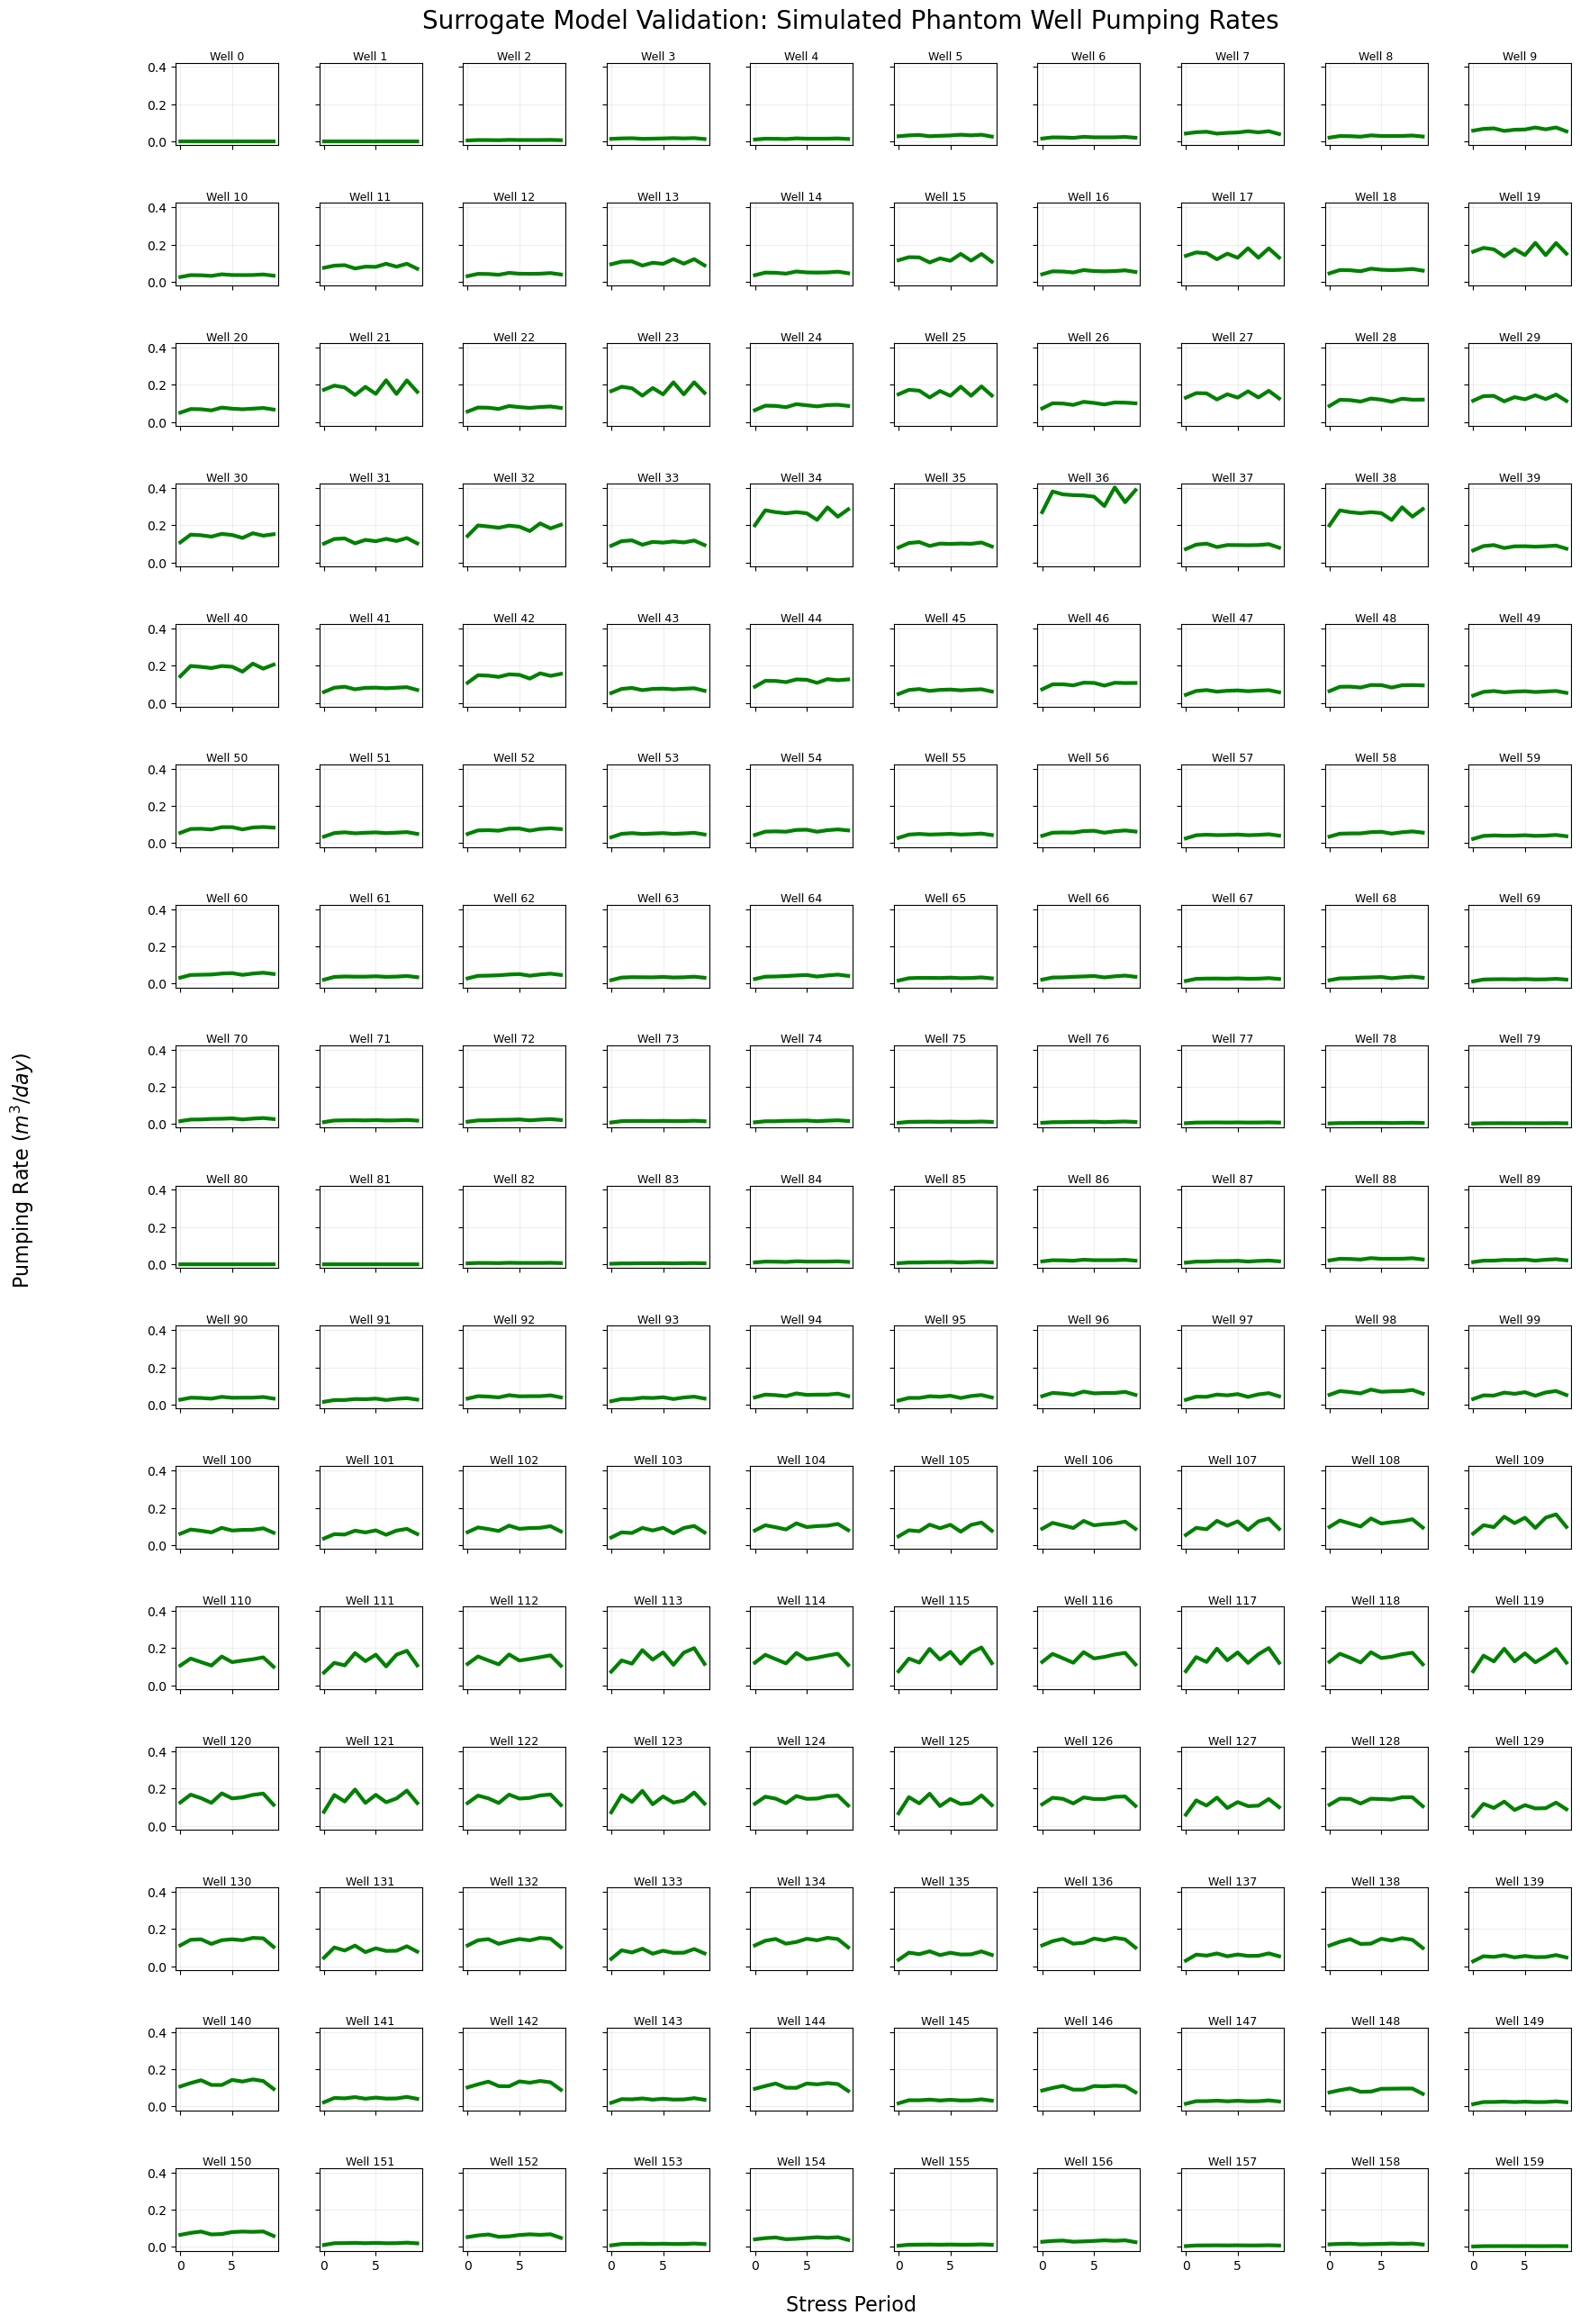

In [9]:
# load optimized pumping rates
results_path = Path.cwd().parent / "results"
pumping = pd.read_csv(results_path / f"{root}_optimized_pumping.csv", index_col=0)

n_periods, n_phantom = pumping.shape

# set up the figure with a grid of subplots
rows, cols = 16, 10
fig, axes = plt.subplots(rows, cols, figsize=(20, 30), sharex=True, sharey=True)
axes_flat = axes.flatten()

print(f"Plotting optimized pumping rates for all {n_phantom} phantom wells...")

for i in range(len(axes_flat)):
    ax = axes_flat[i]
    
    if i < n_phantom:
        ax.plot(pumping.index, pumping.iloc[:, i], 'g-', lw=3)
        
        ax.set_title(f"Well {i}", fontsize=9, pad=2)
        ax.grid(True, alpha=0.2)
    else:
        ax.axis('off')

# global title and legend
fig.suptitle("Surrogate Model Validation: Simulated Phantom Well Pumping Rates", fontsize=20, y=0.93)

# common x and y labels
fig.text(0.5, 0.08, 'Stress Period', ha='center', va='center', fontsize=16)
fig.text(0.04, 0.5, 'Pumping Rate ($m^3/day$)', ha='center', va='center', rotation='vertical', fontsize=16)

plt.subplots_adjust(hspace=0.7, wspace=0.4, bottom=0.1, top=0.91)
plt.show()
